In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
join = os.path.join
from tqdm import tqdm
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import monai
from segment_anything import SamPredictor, sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
import skimage
# MOI ajout des imports qui sont partout dans le doc ici : 
import tarfile
import nibabel as nib
import glob
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import seaborn as sns
import pickle
import pandas as pd # Ajouté pour les stats
import fonctions as fc

In [2]:
import importlib
import fonctions as fc
importlib.reload(fc)

<module 'fonctions' from '/home/cassa2/psy3019/projet/codes_reproductibles/fonctions.py'>

In [4]:
with open("resultats/results_test.pkl", "rb") as f:
    results_load = pickle.load(f)

print(list(results_load.keys()))  # les sujets
print(list(next(iter(results_load.values())).keys()))  # les variables

['BraTS2021_00003', 'BraTS2021_00005', 'BraTS2021_00006', 'BraTS2021_00008', 'BraTS2021_00009', 'BraTS2021_00011', 'BraTS2021_00012', 'BraTS2021_00014', 'BraTS2021_00016', 'BraTS2021_00017', 'BraTS2021_00018', 'BraTS2021_00019', 'BraTS2021_00020', 'BraTS2021_00021', 'BraTS2021_00022', 'BraTS2021_00024', 'BraTS2021_00025', 'BraTS2021_00026', 'BraTS2021_00028', 'BraTS2021_00030', 'BraTS2021_00031', 'BraTS2021_00032', 'BraTS2021_00033', 'BraTS2021_00035', 'BraTS2021_00036', 'BraTS2021_00043', 'BraTS2021_00044', 'BraTS2021_00045', 'BraTS2021_00046', 'BraTS2021_00048', 'BraTS2021_00049', 'BraTS2021_00051', 'BraTS2021_00052', 'BraTS2021_00053', 'BraTS2021_00054', 'BraTS2021_00056', 'BraTS2021_00058', 'BraTS2021_00059', 'BraTS2021_00060', 'BraTS2021_00061', 'BraTS2021_00062', 'BraTS2021_00063', 'BraTS2021_00064', 'BraTS2021_00066', 'BraTS2021_00068']
['slice_index', 'image', 'gt', 'sam_seg', 'medsam_seg']


In [15]:
# Make initial table 

tableau_resultat = pd.DataFrame(index=results_load.keys())
tableau_resultat["slice_index"] = [results_load[s]["slice_index"] for s in results_load]
print(tableau_resultat)

                 slice_index
BraTS2021_00000           62
BraTS2021_00002           68


In [16]:
for sujet in tableau_resultat.index:

    sam_seg = results_load[sujet]['sam_seg']
    medsam_seg = results_load[sujet]['medsam_seg']
    gt = results_load[sujet]['gt']

    # Enlève les dimmensions de 1 retournés par les modèles (nb images traités en mê temps)
    sam_seg = sam_seg.squeeze()
    medsam_seg = medsam_seg.squeeze()

    # Ajout colone dice score 
    sam_dsc = fc.compute_dice_coefficient(gt > 0, sam_seg > 0)
    medsam_dsc = fc.compute_dice_coefficient(gt > 0, medsam_seg > 0)

    # Ajout colone precision, recall 
    precision_sam, recall_sam = fc.precision_recall(gt > 0, sam_seg > 0)
    precision_medsam, recall_medsam = fc.precision_recall(gt > 0, medsam_seg > 0)
    
    print(gt.shape, sam_seg.shape)

    HD100_sam = fc.compute_hd100(gt > 0, sam_seg > 0)
    HD100_medsam = fc.compute_hd100(gt > 0, medsam_seg > 0)

    tableau_resultat.loc[sujet, "sam_dice"] = sam_dsc
    tableau_resultat.loc[sujet, "sam_precision"] = precision_sam
    tableau_resultat.loc[sujet, "sam_recall"] = recall_sam
    tableau_resultat.loc[sujet, "sam_HD100"] = HD100_sam

    tableau_resultat.loc[sujet, "medsam_dice"] = medsam_dsc
    tableau_resultat.loc[sujet, "medsam_precision"] = precision_medsam
    tableau_resultat.loc[sujet, "medsam_recall"] = recall_medsam
    tableau_resultat.loc[sujet, "medsam_HD100"] = HD100_medsam

print(tableau_resultat)
print(tableau_resultat.columns)

(240, 240) (240, 240)
(240, 240) (240, 240)
(240, 240) (240, 240)
(240, 240) (240, 240)
(240, 240) (240, 240)
(240, 240) (240, 240)
                 slice_index  sam_dice  sam_precision  sam_recall  sam_HD100  \
BraTS2021_00000           62  0.729092       0.990933    0.576706  18.384776   
BraTS2021_00002           68  0.710285       0.998738    0.551114  29.832868   

                 medsam_dice  medsam_precision  medsam_recall  medsam_HD100  
BraTS2021_00000     0.826658          0.815415       0.838216     11.401754  
BraTS2021_00002     0.798811          0.847804       0.755171     17.888544  
Index(['slice_index', 'sam_dice', 'sam_precision', 'sam_recall', 'sam_HD100',
       'medsam_dice', 'medsam_precision', 'medsam_recall', 'medsam_HD100'],
      dtype='str')


Dice : Quantifie le chevauchement 
Précision : Si il déborde  
Recall : Si il manque des éléments de la tumeur 
HD100 : (Hausdorff classique, sans percentile) capte le pire débordement


In [6]:
sujet = 'BraTS2021_00000'

sam_seg = results_load[sujet]['sam_seg']
medsam_seg = results_load[sujet]['medsam_seg']
gt = results_load[sujet]['gt']




print(precision_medsam)

0.8476407049459921


In [ ]:
data_path = 'aa'
print(os.path.join(data_path + "/results_test.pkl"))

aa./results_test.pkl


# Visualisations

In [2]:
import pandas as pd
tableau_resultat = pd.read_csv('./resultats/resultats_tableau.csv', index_col=0)
print(tableau_resultat)

                 slice_index  sam_dice  sam_precision  sam_recall  sam_HD100  \
BraTS2021_00003           97  0.900677       0.974032    0.837596  19.313208   
BraTS2021_00005           87  0.673451       0.986450    0.511236  18.027756   
BraTS2021_00006           73  0.890062       0.977382    0.817065  28.442925   
BraTS2021_00008           59  0.779736       0.988827    0.643636  13.416408   
BraTS2021_00009           59  0.834646       0.966565    0.734411   3.605551   
BraTS2021_00011           79  0.869301       0.909669    0.832363  14.422205   
BraTS2021_00012           93  0.890059       0.922051    0.860213  27.459060   
BraTS2021_00014           46  0.941090       0.936635    0.945588   3.605551   
BraTS2021_00016           62  0.630010       1.000000    0.459864  28.000000   
BraTS2021_00017          100  0.706323       0.783784    0.642796  19.416488   
BraTS2021_00018          107  0.905960       0.980551    0.841915  13.038405   
BraTS2021_00019           77  0.795206  

In [3]:
# Mettre dans le bon format
df_sam = tableau_resultat[['sam_dice', 'sam_precision', 'sam_recall', 'sam_HD100']].copy()
df_sam.columns = ['dice', 'precision', 'recall', 'HD100']
df_sam['modele'] = 'SAM'

df_medsam = tableau_resultat[['medsam_dice', 'medsam_precision', 'medsam_recall', 'medsam_HD100']].copy()
df_medsam.columns = ['dice', 'precision', 'recall', 'HD100']
df_medsam['modele'] = 'MedSAM'

df_long = pd.concat([df_sam, df_medsam])

/tmp/ipykernel_17144/2185980298.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x='modele', y='dice',
/tmp/ipykernel_17144/2185980298.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_long, x='modele', y='dice',
/tmp/ipykernel_17144/2185980298.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['SAM', 'MedSAM'], fontsize=12)


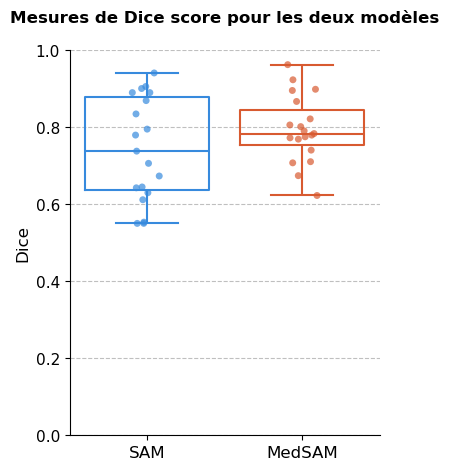

In [7]:
# Dice seul
import seaborn as sns

fig, ax = plt.subplots(figsize=(4, 5))

sns.boxplot(data=df_long, x='modele', y='dice',
            palette={'SAM': '#378ADD', 'MedSAM': '#D85A30'},
            fill=False, linewidth=1.5, fliersize=0, ax=ax)

sns.stripplot(data=df_long, x='modele', y='dice',
              palette={'SAM': '#378ADD', 'MedSAM': '#D85A30'},
              alpha=0.7, jitter=True, dodge=False, legend=False,
              size=5, ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Dice', fontsize=12)
ax.set_xticklabels(['SAM', 'MedSAM'], fontsize=12)
ax.set_ylim(0, 1)
ax.yaxis.set_tick_params(labelsize=11)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('./figures/boxplot_dice.png', dpi=300, bbox_inches='tight')
plt.title('Mesures de Dice score pour les deux modèles', fontsize=12, loc='center', pad=20, fontweight='bold')
plt.show()
plt.close()

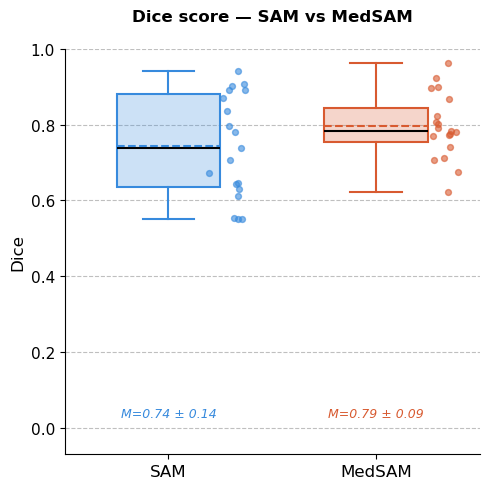

In [10]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(5, 5))

modeles = ['SAM', 'MedSAM']
couleurs = {'SAM': '#378ADD', 'MedSAM': '#D85A30'}

# --- Boxplot avec transparence via boxprops ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele][['modele', 'dice']]
    bp = ax.boxplot(
        vals['dice'],
        positions=[i],
        widths=0.5,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color=couleurs[modele], linewidth=1.5),
        capprops=dict(color=couleurs[modele], linewidth=1.5),
        boxprops=dict(facecolor=couleurs[modele] + '40',   # '40' ≈ 25% opacité
                      edgecolor=couleurs[modele], linewidth=1.5),
        flierprops=dict(marker=''),
        showfliers=False
    )

    # Ligne de moyenne tiretée
    mu = vals['dice'].mean()
    ax.hlines(mu, i - 0.25, i + 0.25,
              colors=couleurs[modele], linewidths=1.5,
              linestyles='--', zorder=5)

# --- Points décalés à droite ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele]['dice']
    x = np.random.normal(i + 0.32, 0.04, size=len(vals))
    ax.scatter(x, vals, color=couleurs[modele], alpha=0.6, s=18, zorder=3)

# --- Annotations μ ± σ ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele]['dice']
    mu, sigma = vals.mean(), vals.std()
    ax.annotate(
        f'M={mu:.2f} ± {sigma:.2f}',
        xy=(i, 0.02), ha='center', va='bottom',
        fontsize=9, color=couleurs[modele], fontstyle='italic'
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(['SAM', 'MedSAM'], fontsize=12)
ax.set_ylabel('Dice', fontsize=12)
ax.set_xlabel('')
ax.set_ylim(-0.07, 1)
ax.yaxis.set_tick_params(labelsize=11)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('Dice score — SAM vs MedSAM', fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./figures/boxplot_dice.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

/tmp/ipykernel_1657/230326323.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Precision', 'Recall'], fontsize=12)


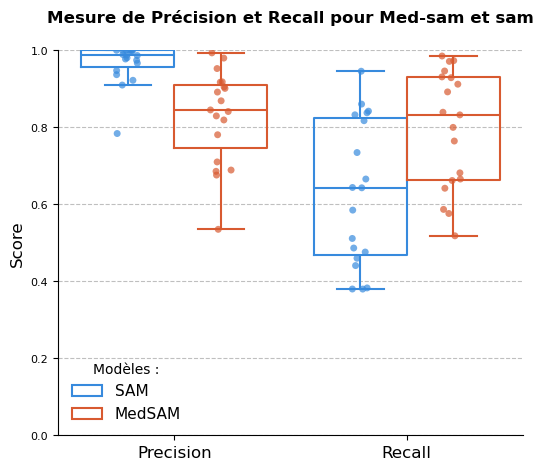

In [40]:
fig, ax = plt.subplots(figsize=(6, 5))

df_pr = df_long.melt(id_vars='modele', value_vars=['precision', 'recall'],
                     var_name='metrique', value_name='valeur')

sns.boxplot(data=df_pr, x='metrique', y='valeur', hue='modele',
            palette={'SAM': '#378ADD', 'MedSAM': '#D85A30'},
            fill=False, linewidth=1.5, fliersize=0, ax=ax)

sns.stripplot(data=df_pr, x='metrique', y='valeur', hue='modele',
              palette={'SAM': '#378ADD', 'MedSAM': '#D85A30'},
              alpha=0.7, jitter=True, dodge=True, legend=False,
              size=5, ax=ax)

ax.set_xlabel('')
ax.set_ylabel('Score', fontsize=12)
ax.set_xticklabels(['Precision', 'Recall'], fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Mesure de Précision et Recall pour Med-sam et sam', fontsize=12, loc='center', pad=20, fontweight='bold')
ax.yaxis.set_tick_params(labelsize=8)

# Grille discrète
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)

# Bordures
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Légende
ax.legend(title='Modèles :', fontsize=11, frameon=False)
legend = ax.legend(title='Modèles :', fontsize=11, frameon=False)
legend.get_title().set_horizontalalignment('left')

#plt.savefig('./figures/boxplot_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [15]:
print(tableau_resultat['medsam_HD100'].describe)

<bound method NDFrame.describe of BraTS2021_00003     3.162278
BraTS2021_00005    13.000000
BraTS2021_00006    10.049876
BraTS2021_00008     5.000000
BraTS2021_00009    11.401754
BraTS2021_00011    14.866069
BraTS2021_00012    16.031220
BraTS2021_00014    13.000000
BraTS2021_00016    20.880613
BraTS2021_00017     8.944272
BraTS2021_00018    11.000000
BraTS2021_00019    14.317821
BraTS2021_00020    17.000000
BraTS2021_00021    29.068884
BraTS2021_00022    10.198039
BraTS2021_00024    12.369317
BraTS2021_00025    12.000000
BraTS2021_00026    10.049876
BraTS2021_00028     7.071068
Name: medsam_HD100, dtype: float64>


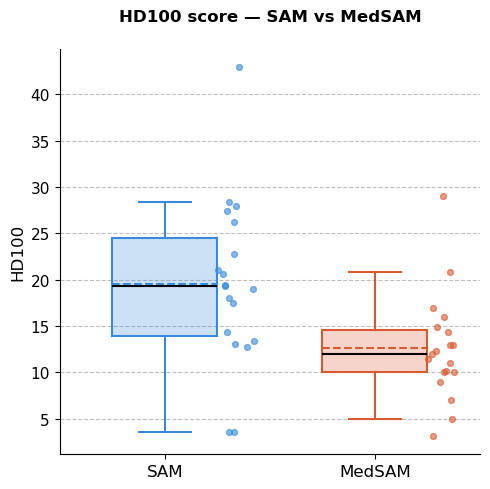

In [16]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(5, 5))

modeles = ['SAM', 'MedSAM']
couleurs = {'SAM': '#378ADD', 'MedSAM': '#D85A30'}

# --- Boxplot avec transparence via boxprops ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele][['modele', 'HD100']]
    bp = ax.boxplot(
        vals['HD100'],
        positions=[i],
        widths=0.5,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(color=couleurs[modele], linewidth=1.5),
        capprops=dict(color=couleurs[modele], linewidth=1.5),
        boxprops=dict(facecolor=couleurs[modele] + '40',   # '40' ≈ 25% opacité
                      edgecolor=couleurs[modele], linewidth=1.5),
        flierprops=dict(marker=''),
        showfliers=False
    )

    # Ligne de moyenne tiretée
    mu = vals['HD100'].mean()
    ax.hlines(mu, i - 0.25, i + 0.25,
              colors=couleurs[modele], linewidths=1.5,
              linestyles='--', zorder=5)

# --- Points décalés à droite ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele]['HD100']
    x = np.random.normal(i + 0.32, 0.04, size=len(vals))
    ax.scatter(x, vals, color=couleurs[modele], alpha=0.6, s=18, zorder=3)

# --- Annotations μ ± σ ---
for i, modele in enumerate(modeles):
    vals = df_long[df_long['modele'] == modele]['HD100']
    mu, sigma = vals.mean(), vals.std()
    ax.annotate(
        f'M={mu:.2f} ± {sigma:.2f}',
        xy=(i, 0.02), ha='center', va='bottom',
        fontsize=9, color=couleurs[modele], fontstyle='italic'
    )

ax.set_xticks([0, 1])
ax.set_xticklabels(['SAM', 'MedSAM'], fontsize=12)
ax.set_ylabel('HD100', fontsize=12)
ax.set_xlabel('')
#ax.set_ylim(-0.07, 1)
ax.yaxis.set_tick_params(labelsize=11)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title('HD100 score — SAM vs MedSAM', fontsize=12, pad=20, fontweight='bold')
plt.tight_layout()
plt.savefig('./figures/boxplot_dice.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Get lowest scores 

In [6]:
tableau_resultat = pd.read_csv('./resultats/resultats_tableau.csv', index_col=0)
print(tableau_resultat.columns)

Index(['slice_index', 'sam_dice', 'sam_precision', 'sam_recall', 'sam_HD100',
       'medsam_dice', 'medsam_precision', 'medsam_recall', 'medsam_HD100'],
      dtype='str')


In [9]:
print(tableau_resultat.sort_values(by='sam_dice').head(5).index)

Index(['BraTS2021_00031', 'BraTS2021_00064', 'BraTS2021_00068',
       'BraTS2021_00058', 'BraTS2021_00026'],
      dtype='str')


In [10]:
print(tableau_resultat.nsmallest(5, 'sam_dice'))

                 slice_index  sam_dice  sam_precision  sam_recall   sam_HD100  \
BraTS2021_00031           87  0.000000       0.000000    0.000000  102.122475   
BraTS2021_00064           54  0.000000       0.000000    0.000000   24.698178   
BraTS2021_00068           97  0.138686       1.000000    0.074510   22.472205   
BraTS2021_00058           83  0.169975       1.000000    0.092881   30.463092   
BraTS2021_00026           66  0.550360       0.998221    0.379910   22.803509   

                 medsam_dice  medsam_precision  medsam_recall  medsam_HD100  
BraTS2021_00031     0.846746          0.913667       0.788959     20.000000  
BraTS2021_00064     0.489734          0.840731       0.345494     15.652476  
BraTS2021_00068     0.271318          0.921053       0.159091     11.661904  
BraTS2021_00058     0.331595          0.952096       0.200758     18.384776  
BraTS2021_00026     0.783606          0.952550       0.665562     10.049876  


In [11]:
print(tableau_resultat.nsmallest(5, 'medsam_dice'))

                 slice_index  sam_dice  sam_precision  sam_recall  sam_HD100  \
BraTS2021_00068           97  0.138686       1.000000    0.074510  22.472205   
BraTS2021_00058           83  0.169975       1.000000    0.092881  30.463092   
BraTS2021_00064           54  0.000000       0.000000    0.000000  24.698178   
BraTS2021_00051          107  0.622807       0.992376    0.453806  19.209373   
BraTS2021_00025           83  0.644940       1.000000    0.475949  20.615528   

                 medsam_dice  medsam_precision  medsam_recall  medsam_HD100  
BraTS2021_00068     0.271318          0.921053       0.159091     11.661904  
BraTS2021_00058     0.331595          0.952096       0.200758     18.384776  
BraTS2021_00064     0.489734          0.840731       0.345494     15.652476  
BraTS2021_00051     0.558008          0.626429       0.503061     17.262677  
BraTS2021_00025     0.622812          0.780585       0.518094     12.000000  


# Archive

In [ ]:
def verification_slice_tumeur(subject_id, scan_path, gt_path, slice_index, scan_2d, gt_2d, max_attempts=10):

    if np.sum(gt_2d) > 0:
        print('Slice initiale fonctionne', slice_index)
        return slice_index, scan_2d, gt_2d

    # Seulement ici on charge le 3D
    print(f'Slice initiale sans tumeur ({slice_index}), chargement volume 3D...')
    scan_obj = nib.load(scan_path)
    gt_obj = nib.load(gt_path)
    image_3d = scan_obj.get_fdata()
    gt_3d = gt_obj.get_fdata()

    for _ in range(max_attempts):
        new_index = np.random.randint(10,140)
        new_image, new_gt = fc.get_slice_pair(new_index, image_3d, gt_3d)
        if np.sum(new_gt) > 0:
            print(f'Slice trouvée: {new_index}')
            return new_index, new_image, new_gt

    print(f"Aucune slice valide pour {subject_id}, retour à la slice initiale")
    return slice_index, scan_2d, gt_2d

def get_statistic_socre_on_dataset(data_path):
    
    # Valeurs à stocker 
    results = {}
    sam_predictor, med_sam_predictor, med_sam_model = fc.initialisation_modeles()
    print('Initialisation terminée')

    # Boucle qui run trough les participants et extrait paths 
    for subject_folder in sorted(os.scandir(data_path), key=lambda e: e.name):
        
        subject_id = subject_folder.name
        print('Commence pour', subject_id) # Savoir je suis rendue ou 

        # Path des fichiers
        scan_path = os.path.join(subject_folder.path, f"{subject_id}_t2.nii.gz")
        gt_path = os.path.join(subject_folder.path, f"{subject_id}_seg.nii.gz")

        if not os.path.exists(scan_path) or not os.path.exists(gt_path):
            print(f"Fichiers manquants pour {subject_id}, skipping...")
            continue
        
        slice_index = np.random.randint(10,140)
        scan_2d_og, gt_2d = fc.load_scan_2d(scan_path, gt_path, slice_index)

        # Vérifie qu'il y a une tumeur sur la slice originale ou dans 10 autres essais suivant
        slice_index, scan_2d_og, gt_2d = verification_slice_tumeur(subject_id, scan_path, gt_path, slice_index, scan_2d_og, gt_2d)
        
        scan_2d = fc.sam_imput_format(scan_2d_og)  # après la vérification, pas avant

        # Obtenir la boite autour de la segmentation 
        gt_box = fc.get_bbox_from_mask(gt_2d)

        # Mettre dans le format nécésaire pour les modèles
        #scan_2d_pre = fc.preprocess_scan(scan_2d)

        # Segmentation des deux modèles 
        #sam_seg, medsam_seg = fc.get_2_both_seg_scan(scan_2d_pre, gt_2d, sam_predictor, med_sam_model)
        #print('Segmentation terminée', subject_id)

        results[subject_id] = {
        "slice_index": slice_index,
        "image": scan_2d_og,
        "gt": gt_2d
        #"sam_seg": sam_seg,
        #"medsam_seg": medsam_seg,
        }
    
    print('boucle terminée :)')

    # Sauvegarde 
    output_path = os.path.join("./results_test.pkl")
    with open(output_path, "wb") as f:
        pickle.dump(results, f)

    print(f"Résultats sauvegardés dans : {output_path}")

    return results




In [13]:
results = get_statistic_socre_on_dataset("../data_test")


Initialisation terminée
Commence pour BraTS2021_00000
Slice initiale sans tumeur (124), chargement volume 3D...
Slice trouvée: 59
Commence pour BraTS2021_00002
Slice initiale sans tumeur (137), chargement volume 3D...
Slice trouvée: 98
boucle terminée :)
Résultats sauvegardés dans : ./results_test.pkl
